In [15]:
## Download the RADARSAT 2002 elevation data ##

from pathlib import Path
from shutil import copyfileobj
from urllib.request import urlopen
import pandas as pd
import geopandas as gpd
import json
import math
import numpy as np

import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, MaxNLocator
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

from affine import Affine

import rasterio
from rasterio.mask import mask
from rasterio.enums import Resampling
from rasterio.features import geometry_mask
from rasterio.transform import array_bounds
from rasterio.vrt import WarpedVRT
from rasterio.warp import transform_bounds

from scipy import ndimage as ndi

project_dir = Path.cwd()
input_dir = project_dir / "Input_Data"
dem_input_dir = input_dir / "Heard_DEM_2002"

dem_input_dir.mkdir(parents = True, exist_ok = True)

# Download the elevation grid and its documentation from AADC.
download_base = (
    "https://data.aad.gov.au/eds/api/dataset/"
    "C8912E96-5BBE-45B3-AD1E-BB82E8082ADD/object/download?prefix=")

dem_files = [
    "heard_dem_radarsat2002.asc",
    "heard_dem_radarsat2002.prj",
    "ArcInfo_ascii_format.txt",
    "README",
    "LICENSE",
    "heard_dem_radarsat02.xml"]

for filename in dem_files:
    target_path = dem_input_dir / filename

    if target_path.exists():
        print(f"Already present: {filename}")
        continue

    print(f"Downloading: {filename}", flush = True)
    temporary_path = target_path.with_name(target_path.name + ".part")

    with urlopen(download_base + filename, timeout = 60) as response:
        with temporary_path.open("wb") as output:
            copyfileobj(response, output, length = 1024 * 1024)

    temporary_path.replace(target_path)

print(f"DEM inputs ready: {dem_input_dir.relative_to(project_dir)}")

Already present: heard_dem_radarsat2002.asc
Already present: heard_dem_radarsat2002.prj
Already present: ArcInfo_ascii_format.txt
Already present: README
Already present: LICENSE
Already present: heard_dem_radarsat02.xml
DEM inputs ready: Input_Data\Heard_DEM_2002


In [3]:
## Prepare the RADARSAT 2002 elevation raster ##

processed_dir = project_dir / "Output_Data" / "processed"
geomorphology_dir = processed_dir / "geomorphology"

geomorphology_dir.mkdir(parents = True, exist_ok = True)

dem_source_path = dem_input_dir / "heard_dem_radarsat2002.asc"
dem_path = geomorphology_dir / "Heard_DEM_2002.tif"

# Preserve the source grid and elevations in a compressed GeoTIFF.
# The documented coordinates are WGS84 / UTM zone 43S.
with rasterio.open(dem_source_path) as source:
    profile = source.profile.copy()
    profile.update(
        driver = "GTiff",
        dtype = "float32",
        crs = "EPSG:32743",
        count = 1,
        compress = "deflate",
        tiled = True,
        blockxsize = 256,
        blockysize = 256)

    with rasterio.open(dem_path, "w", **profile) as destination:
        destination.write(source.read(1).astype("float32"), 1)

with rasterio.open(dem_path) as source:
    print(f"Saved: {dem_path.relative_to(project_dir)}")
    print(f"CRS: {source.crs}")
    print(f"Pixel size: {source.res}")
    print(f"Shape: {source.height} rows × {source.width} columns")
    print(f"NoData: {source.nodata}")

C:\Users\harry\AppData\Local\Temp\ipykernel_39228\3284926943.py:26: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  destination.write(source.read(1).astype("float32"), 1)


Saved: Output_Data\processed\geomorphology\Heard_DEM_2002.tif
CRS: EPSG:32743
Pixel size: (10.000000000274, 10.000000000274)
Shape: 5215 rows × 5298 columns
NoData: -9999.0


In [4]:
## Clip a copy of the DEM to the coastline ##

coast_path = input_dir / "HIMI_Features" / "himi_coastline_py.gpkg"
dem_original_path = geomorphology_dir / "Heard_DEM_2002.tif"
dem_land_path = geomorphology_dir / "Heard_DEM_2002_land.tif"

# Read the original without modifying it.
with rasterio.open(dem_original_path) as source:
    coastline = gpd.read_file(coast_path).to_crs(source.crs)
    coastline = coastline.loc[
        coastline.geometry.notna() & ~coastline.geometry.is_empty].copy()

    # Mask offshore pixels and crop on the existing grid.
    dem_land, land_transform = mask(
        source,
        coastline.geometry,
        indexes = [1],
        crop = True,
        all_touched = False,
        nodata = -9999,
        filled = False)

    land_profile = source.profile.copy()
    land_profile.update(
        height = dem_land.shape[1],
        width = dem_land.shape[2],
        transform = land_transform,
        count = 1,
        nodata = -9999)

# Save the clipped raster as a separate file.
with rasterio.open(dem_land_path, "w", **land_profile) as destination:
    destination.write(dem_land.filled(-9999))

# Use the clipped copy in subsequent cells.
dem_path = dem_land_path

print(f"Original retained: {dem_original_path.relative_to(project_dir)}")
print(f"Clipped copy: {dem_land_path.relative_to(project_dir)}")
print(f"Clipped shape: {dem_land.shape[1]} rows × {dem_land.shape[2]} columns")

Original retained: Output_Data\processed\geomorphology\Heard_DEM_2002.tif
Clipped copy: Output_Data\processed\geomorphology\Heard_DEM_2002_land.tif
Clipped shape: 3261 rows × 4734 columns


In [5]:
## Inspect the ice thickness inputs ##

thickness_dir = input_dir / "RGI-19_Ice_Thickness"
thickness_path = thickness_dir / "THICKNESS_RGI-19.3_2021July09.tif"
thickness_error_path = thickness_dir / "ERRTHICKNESS_RGI-19.3_2021July09.tif"

# Compare the source grids and recorded value units.
raster_paths = {
    "Surface DEM": dem_path,
    "Modelled thickness": thickness_path,
    "Thickness error": thickness_error_path}

metadata_records = []

for label, path in raster_paths.items():
    with rasterio.open(path) as source:
        metadata_records.append({
            "Input": label,
            "File": path.name,
            "CRS": str(source.crs),
            "Pixel size": source.res,
            "Shape (rows, columns)": (source.height, source.width),
            "Bounds": tuple(source.bounds),
            "Data type": source.dtypes[0],
            "NoData": source.nodata if source.nodata is not None else "Not recorded",
            "Band units": source.units[0] or "Not recorded",
            "Scale": source.scales[0],
            "Offset": source.offsets[0]})

raster_metadata = pd.DataFrame(metadata_records).set_index("Input").T

display(raster_metadata)

# Read the documentation supplied with the thickness product.
readme_path = thickness_dir / "README.txt"

if readme_path.exists():
    print("\nThickness README:\n")
    print(readme_path.read_text(encoding = "utf-8-sig", errors = "replace"))

Input,Surface DEM,Modelled thickness,Thickness error
File,Heard_DEM_2002_land.tif,THICKNESS_RGI-19.3_2021July09.tif,ERRTHICKNESS_RGI-19.3_2021July09.tif
CRS,EPSG:32743,EPSG:32742,EPSG:32742
Pixel size,"(10.000000000274, 10.000000000274)","(50.0, 50.0)","(50.0, 50.0)"
"Shape (rows, columns)","(3261, 4734)","(474, 636)","(474, 636)"
Bounds,"(378169.18999852, 4104982.8779988466, 425509.1...","(785500.0, 4096800.0, 817300.0, 4120500.0)","(785500.0, 4096800.0, 817300.0, 4120500.0)"
Data type,float32,float32,float32
NoData,-9999.0,0.0,0.0
Band units,Not recorded,Not recorded,Not recorded
Scale,1.0,1.0,1.0
Offset,0.0,0.0,0.0



Thickness README:

Millan, R., Mouginot, J. & Rabatel, A. (2021).  Ice velocity and thickness of the world's glaciers.  [dataset].  Theia.  https://doi.org/10.6096/1007

https://www.sedoo.fr/theia-publication-products/?uuid=55acbdd5-3982-4eac-89b2-46703557938c


In [6]:
## Align the DEM and thickness tiles on a 50 m grid ##

# Retain the clipped 10 m DEM and create a separate working grid.
with rasterio.open(dem_path) as source:
    working_crs = source.crs
    working_resolution = 50
    working_width = math.ceil(source.width * source.res[0] / working_resolution)
    working_height = math.ceil(source.height * source.res[1] / working_resolution)
    working_transform = source.transform * Affine.scale(
        working_resolution / source.res[0], working_resolution / source.res[1])

working_shape = (working_height, working_width)
left, bottom, right, top = array_bounds(
    working_height, working_width, working_transform)

def read_on_working_grid(path, resampling):
    with rasterio.open(path) as source:
        with WarpedVRT(
            source, crs = working_crs, transform = working_transform,
            width = working_width, height = working_height,
            src_nodata = source.nodata, nodata = np.nan,
            dtype = "float32", resampling = resampling) as aligned:
            data = aligned.read(1, masked = True).filled(np.nan)

        return data * source.scales[0] + source.offsets[0]

# Average DEM elevations to 50 m.
# Use nearest neighbour for thickness so the initial review retains source values.
surface_50m = read_on_working_grid(dem_path, Resampling.average)
thickness_raw_50m = np.full(working_shape, np.nan, dtype = "float32")
error_raw_50m = np.full(working_shape, np.nan, dtype = "float32")
tile_records = []
used_thickness_tiles = []

# Check all tiles rather than assuming 19.3 contains every glacier.
for path in sorted(thickness_dir.glob("THICKNESS_RGI-19.*.tif")):
    with rasterio.open(path) as source:
        tile_left, tile_bottom, tile_right, tile_top = transform_bounds(
            source.crs, working_crs, *source.bounds)

    if (tile_right <= left or tile_left >= right
        or tile_top <= bottom or tile_bottom >= top):
        continue

    data = read_on_working_grid(path, Resampling.nearest)
    valid = np.isfinite(data) & (data > 0)
    overlap = valid & np.isfinite(thickness_raw_50m)
    take = valid & ~np.isfinite(thickness_raw_50m)

    # Use the first valid tile in overlaps; never add thicknesses together.
    thickness_raw_50m[take] = data[take]
    error_path = path.with_name("ERR" + path.name)

    if error_path.exists():
        error_data = read_on_working_grid(error_path, Resampling.nearest)
        error_data[error_data < 0] = np.nan
        error_raw_50m[take] = error_data[take]

    tile_records.append({
        "Tile": path.name,
        "Valid pixels": int(valid.sum()),
        "Overlap pixels": int(overlap.sum())})

    if take.any():
        used_thickness_tiles.append(str(path.relative_to(project_dir)))

if not np.isfinite(thickness_raw_50m).any():
    raise ValueError("No valid thickness data overlap the DEM.")

display(pd.DataFrame(tile_records))
print(f"Working grid: {working_crs}, 50 m, {working_shape}")

,Tile,Valid pixels,Overlap pixels
0,THICKNESS_RGI-19.3_2021July09.tif,101328,0


Working grid: EPSG:32743, 50 m, (653, 947)


In [7]:
## Mask lagoons and calculate the candidate bed ##

# Use the coastline already loaded when clipping the DEM.
land_mask = geometry_mask(
    coastline.to_crs(working_crs).geometry,
    out_shape = working_shape, transform = working_transform, invert = True)

lagoon_path = input_dir / "heard_island_shp" / "UpdatedHI_Lagoons2014.shp"
lagoons = gpd.read_file(lagoon_path).to_crs(working_crs)
lagoon_mask = geometry_mask(
    lagoons.geometry,
    out_shape = working_shape, transform = working_transform, invert = True)

surface_50m[~land_mask] = np.nan
thickness_land_50m = np.where(
    land_mask & ~lagoon_mask, thickness_raw_50m, np.nan)
error_land_50m = np.where(
    np.isfinite(thickness_land_50m), error_raw_50m, np.nan)

# Calculate a fixed bed wherever both inputs are available.
# Missing thickness remains unknown, and negative bed elevations are retained.
bed_candidate_50m = surface_50m - thickness_land_50m

# Flag isolated jumps at least 200 m above neighbouring valid thickness values.
neighbours = np.ones((3, 3), dtype = bool)
neighbours[1, 1] = False
valid_thickness = np.isfinite(thickness_land_50m)

neighbour_max = ndi.maximum_filter(
    np.where(valid_thickness, thickness_land_50m, -np.inf),
    footprint = neighbours, mode = "constant", cval = -np.inf)

neighbour_count = ndi.convolve(
    valid_thickness.astype("uint8"), neighbours.astype("uint8"),
    mode = "constant", cval = 0)

spike_candidates = (
    valid_thickness & (neighbour_count >= 4)
    & (thickness_land_50m - neighbour_max >= 200))

# Keep flagged values in the candidate bed until we review them.
excluded_lagoon_pixels = (
    lagoon_mask & land_mask & np.isfinite(thickness_raw_50m))

print(f"Lagoon thickness pixels excluded: {int(excluded_lagoon_pixels.sum()):,}")
print(f"Large local jumps flagged for review: {int(spike_candidates.sum()):,}")

Lagoon thickness pixels excluded: 3,073
Large local jumps flagged for review: 4


In [ ]:
## Save thickness copies and the candidate bed ##

working_profile = {
    "driver": "GTiff", "dtype": "float32", "count": 1,
    "height": working_height, "width": working_width,
    "crs": working_crs, "transform": working_transform,
    "nodata": -9999, "compress": "deflate", "tiled": True,
    "blockxsize": 256, "blockysize": 256}

def save_working_raster(data, filename):
    path = geomorphology_dir / filename
    encoded = np.where(np.isfinite(data), data, -9999).astype("float32")

    with rasterio.open(path, "w", **working_profile) as destination:
        destination.write(encoded[np.newaxis, :, :])
        destination.set_band_unit(1, "m")

    return path

saved_layers = {}

for label, data, filename in (
    ("surface", surface_50m, "Heard_surface_DEM_2002_50m.tif"),
    ("thickness", thickness_land_50m, "Heard_Millan_thickness_land_50m.tif"),
    ("thickness_error", error_land_50m, "Heard_Millan_thickness_error_land_50m.tif"),
    ("candidate_bed", bed_candidate_50m, "Heard_bed_estimate_candidate_50m.tif")):

    saved_layers[label] = save_working_raster(data, filename)

# Make year-specific thickness masks while retaining the same candidate bed.
# The years describe the outlines used, not new thickness measurements.
ice_masks = {}
ice_layers = {}
coverage_records = []
final_dir = processed_dir / "glacier_outlines_final"

for year in (2019, 2026):
    ice = gpd.read_file(
        final_dir / f"Heard_ice_{year}_final.gpkg",
        layer = f"ice_{year}").to_crs(working_crs)

    ice_layers[year] = ice
    ice_masks[year] = geometry_mask(
        ice.geometry, out_shape = working_shape,
        transform = working_transform, invert = True) & land_mask & ~lagoon_mask

    mapped_pixels = int(ice_masks[year].sum())
    covered_pixels = int((ice_masks[year] & valid_thickness).sum())
    year_thickness = np.where(ice_masks[year], thickness_land_50m, np.nan)

    saved_layers[f"thickness_mask_{year}"] = save_working_raster(
        year_thickness, f"Heard_Millan_thickness_mask_{year}_50m.tif")

    coverage_records.append({
        "Outline year": year,
        "Ice pixels": mapped_pixels,
        "Pixels with thickness": covered_pixels,
        "Coverage (%)": 100 * covered_pixels / mapped_pixels if mapped_pixels else np.nan})

# Save review flags separately; zero means no listed issue.
# Flags can combine, so a pixel with flags 1 and 8 would have value 9.
qa = np.zeros(working_shape, dtype = "uint8")
qa[ice_masks[2019] & ~valid_thickness] |= 1
qa[lagoon_mask & np.isfinite(thickness_raw_50m)] |= 2
qa[valid_thickness & ~ice_masks[2019]] |= 4
qa[valid_thickness & ~np.isfinite(surface_50m)] |= 8
qa[valid_thickness & ~np.isfinite(error_land_50m)] |= 16
qa[spike_candidates] |= 32
qa[~land_mask] = 255

flag_definitions = {
    "1": "Missing thickness within the 2019 ice mask",
    "2": "Modelled thickness in an excluded 2014 lagoon",
    "4": "Modelled thickness outside the 2019 ice mask",
    "8": "Missing DEM elevation where thickness exists",
    "16": "Missing thickness error where thickness exists",
    "32": "Local thickness jump of at least 200 m; review only"}

qa_profile = {**working_profile, "dtype": "uint8", "nodata": 255}
qa_path = geomorphology_dir / "Heard_Millan_thickness_QA_50m.tif"

with rasterio.open(qa_path, "w", **qa_profile) as destination:
    destination.write(qa[np.newaxis, :, :])
    destination.update_tags(flag_definitions = json.dumps(flag_definitions))

# Record the inputs and decisions for the methodology section.
bed_metadata = {
    "dem": str(dem_path.relative_to(project_dir)),
    "dem_product": "Heard Island RADARSAT (2002) DEM",
    "thickness_doi": "10.6096/1007",
    "thickness_tiles": used_thickness_tiles,
    "working_crs": str(working_crs),
    "resolution_m": 50,
    "dem_resampling": "average",
    "thickness_resampling": "nearest",
    "lagoon_mask": str(lagoon_path.relative_to(project_dir)),
    "bed_scope": "Pixels with valid DEM and positive modelled thickness, excluding lagoons",
    "spike_policy": "Flag only; values retained in candidate bed",
    "flag_definitions": flag_definitions,
    "outputs": {label: path.name for label, path in saved_layers.items()}}

(geomorphology_dir / "bed_estimate_metadata.json").write_text(
    json.dumps(bed_metadata, indent = 2), encoding = "utf-8")

display(pd.DataFrame(coverage_records).round(2))
print(f"Candidate bed saved: {saved_layers['candidate_bed'].relative_to(project_dir)}")

,Outline year,Ice pixels,Pixels with thickness,Coverage (%)
0,2019,83397,81614,97.86
1,2026,80509,79045,98.18


Candidate bed saved: Output_Data\processed\geomorphology\Heard_bed_estimate_candidate_50m.tif


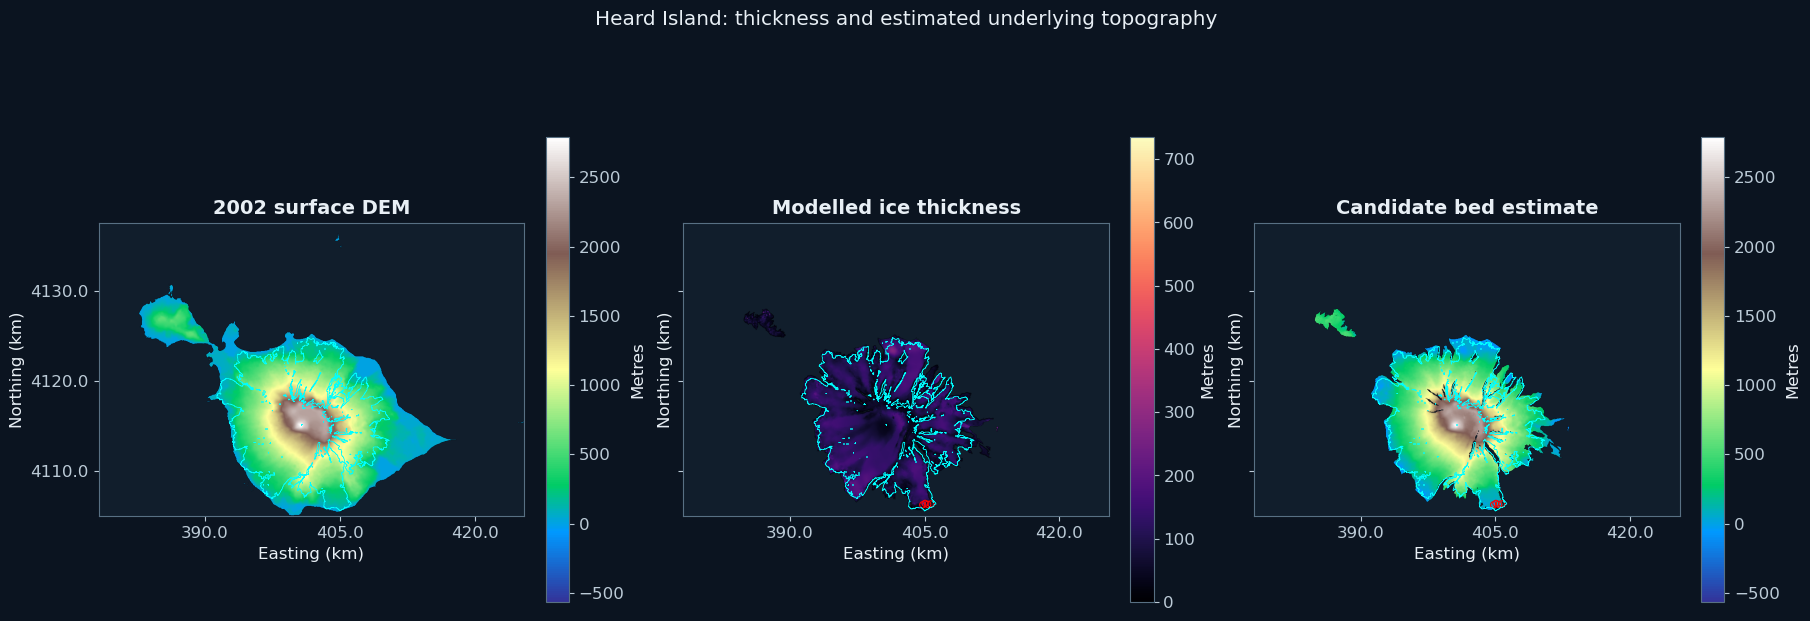

In [9]:
## Preview the surface, thickness and candidate bed ##

style_path = processed_dir / "book_figure_style.json"
book_plot_style = json.loads(style_path.read_text()) if style_path.exists() else {}

# Give the surface and bed panels the same elevation colour scale.
elevation_min = min(0, float(np.nanmin(bed_candidate_50m)))
elevation_max = float(np.nanmax(surface_50m))

with plt.style.context("dark_background"), plt.rc_context(book_plot_style):
    bed_fig, bed_axes = plt.subplots(
        1, 3, figsize = (18, 7), sharex = True, sharey = True,
        layout = "constrained")

    for index, (ax, data, title, cmap) in enumerate(zip(
        bed_axes,
        (surface_50m, thickness_land_50m, bed_candidate_50m),
        ("2002 surface DEM", "Modelled ice thickness", "Candidate bed estimate"),
        ("terrain", "magma", "terrain"))):

        image_options = (
            {"vmin": elevation_min, "vmax": elevation_max}
            if index != 1 else {"vmin": 0})

        plotted = ax.imshow(
            np.ma.masked_invalid(data), origin = "upper",
            extent = (left, right, bottom, top), cmap = cmap, **image_options)

        ice_layers[2019].boundary.plot(
            ax = ax, color = "cyan", linewidth = 0.5)

        ax.set(
            title = title, xlabel = "Easting (km)", ylabel = "Northing (km)",
            xlim = (left, right), ylim = (bottom, top), aspect = "equal")

        ax.xaxis.set_major_formatter(
            FuncFormatter(lambda value, position: f"{value / 1000:.1f}"))
        ax.yaxis.set_major_formatter(
            FuncFormatter(lambda value, position: f"{value / 1000:.1f}"))
        ax.xaxis.set_major_locator(MaxNLocator(4))
        ax.yaxis.set_major_locator(MaxNLocator(4))

        bed_fig.colorbar(plotted, ax = ax, shrink = 0.7, label = "Metres")

        # Mark suspicious thickness jumps for review.
        if index > 0 and spike_candidates.any():
            rows, columns = np.nonzero(spike_candidates)
            x, y = rasterio.transform.xy(working_transform, rows, columns)
            ax.scatter(
                x, y, s = 20, facecolors = "none",
                edgecolors = "red", linewidths = 0.8)

    bed_fig.suptitle("Heard Island: thickness and estimated underlying topography")
    plt.show()

Compute terrain derivatives from the DEM
All using GDAL DEM processing

In [10]:
## Define terrain derivative functions ##

from osgeo import gdal

gdal.UseExceptions()

terrain_dir = geomorphology_dir / "terrain"
terrain_dir.mkdir(parents = True, exist_ok = True)
def slope(dem_path, out_path, units="degree", scale=None, compute_edges=True):
    """Slope raster. units: 'degree' or 'percent'."""
    opts = gdal.DEMProcessingOptions(
        slopeFormat=units,
        scale=scale,
        computeEdges=compute_edges,
        creationOptions=["COMPRESS=LZW"],
    )
    gdal.DEMProcessing(out_path, dem_path, "slope", options=opts)
    return out_path


def aspect(dem_path, out_path, zero_for_flat=False, compute_edges=True):
    """Aspect in degrees clockwise from north. Flat cells are nodata (-9999)
    unless zero_for_flat=True."""
    opts = gdal.DEMProcessingOptions(
        zeroForFlat=zero_for_flat,
        computeEdges=compute_edges,
        creationOptions=["COMPRESS=LZW"],
    )
    gdal.DEMProcessing(out_path, dem_path, "aspect", options=opts)
    return out_path


def hillshade(dem_path, out_path, azimuth=315, altitude=45, z_factor=1.0,
              scale=None, multi_directional=False, combined=False,
              compute_edges=True):
    """Hillshade (0-255). Set multi_directional=True for a softer,
    multi-light-source look that works well in rugged terrain."""
    opts = gdal.DEMProcessingOptions(
        azimuth=azimuth,
        altitude=altitude,
        zFactor=z_factor,
        scale=scale,
        multiDirectional=multi_directional,
        combined=combined,
        computeEdges=compute_edges,
        creationOptions=["COMPRESS=LZW"],
    )
    gdal.DEMProcessing(out_path, dem_path, "hillshade", options=opts)
    return out_path

Plot all of these derivatives

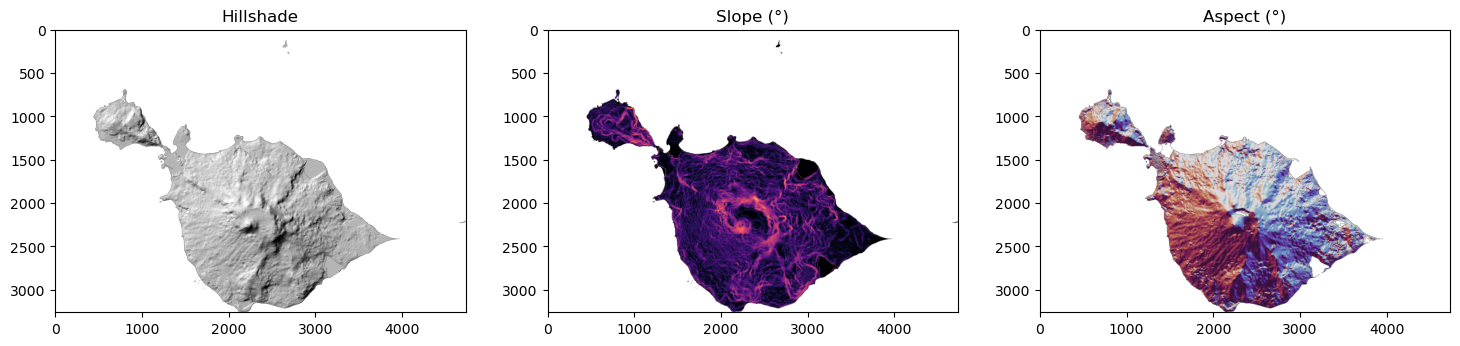

In [12]:
import os

# Save the derivatives next to the other geomorphology outputs.
DEM_DIR = terrain_dir

slope_path     = slope(dem_path, os.path.join(DEM_DIR, "slope.tif"))
aspect_path    = aspect(dem_path, os.path.join(DEM_DIR, "aspect.tif"))
hillshade_path = hillshade(dem_path, os.path.join(DEM_DIR, "hillshade.tif"))




def read_masked(path):
    with rasterio.open(path) as src:
        return src.read(1, masked=True)   # nodata automatically masked


fig, ax = plt.subplots(1, 3, figsize=(18, 6))
ax[0].imshow(read_masked(hillshade_path), cmap="gray");  ax[0].set_title("Hillshade")
ax[1].imshow(read_masked(slope_path), cmap="magma");     ax[1].set_title("Slope (°)")
ax[2].imshow(read_masked(aspect_path), cmap="twilight"); ax[2].set_title("Aspect (°)")
plt.show()